## **!!_8_Suitability of NNF for a hyperbolic paraboloid**

FULL DATASET (441 points, one outlier)
Removed normal points: 396
Remaining points: 45 (outliers: 1)
Outlier percentage: 2.22%
The true outlier is at index 24 (zero-based index 23)

Q = 45, N_x = 2, N_y = 1
N_min = 2.3106, N_max = 31.6667

Processed N = 0
Processed N = 10
Processed N = 20
Processed N = 30
Processed N = 40
Processed N = 50
Processed N = 60
Processed N = 70
Processed N = 80

Values of N for which the error on the true outlier exceeds all others:
[2, 3, 4, 5, 7, 8, 9, 10, 12, 14, 15, 16, 17, 19, 20, 28, 53, 63]


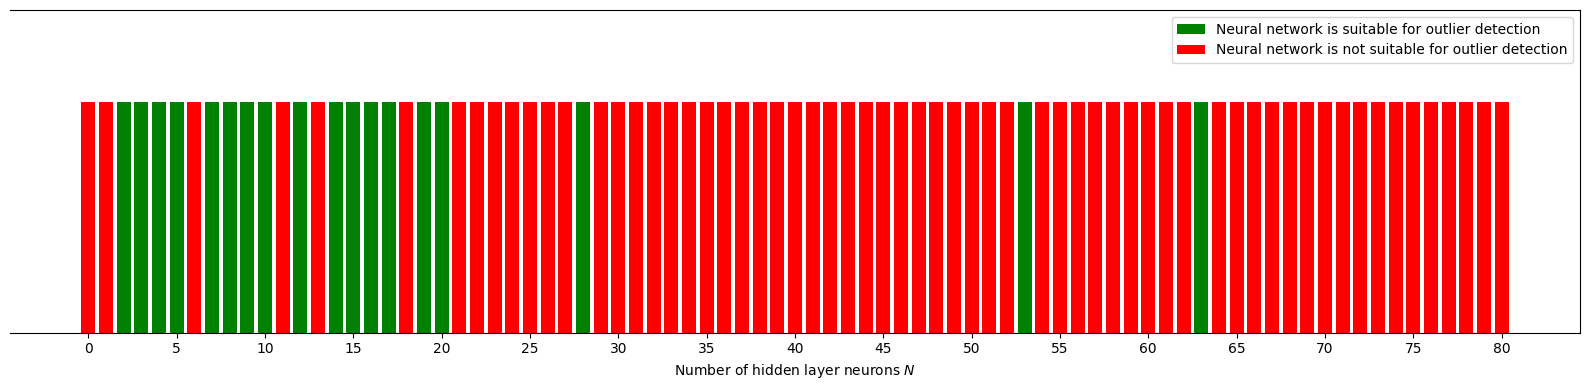

In [ ]:
import sys
!{sys.executable} -m pip install --upgrade pyod

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import math
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 1. Generation of the full hyperbolic paraboloid dataset with an outlier
#    Features: x1, x2 ; target variable: y = x1^2 - x2^2
# ------------------------------------------------------------
x1 = np.arange(-1.0, 1.05, 0.1)
x2 = np.arange(-1.0, 1.05, 0.1)
X1grid, X2grid = np.meshgrid(x1, x2)
Ygrid = X1grid**2 - X2grid**2

# Inject outlier at point (x1=0, x2=0) with value y = 0.45
mask_out = (np.abs(X1grid) < 1e-10) & (np.abs(X2grid) < 1e-10)
Ygrid[mask_out] = 0.45

points_full = np.column_stack((X1grid.ravel(), X2grid.ravel(), Ygrid.ravel()))
labels_full = np.zeros(len(points_full), dtype=int)
labels_full[np.where(mask_out.ravel())[0]] = 1

print("="*80)
print("FULL DATASET (441 points, one outlier)")
print("="*80)

# ------------------------------------------------------------
# 2. Random removal of 90% of normal points
# ------------------------------------------------------------
np.random.seed(42)
normal_indices = np.where(labels_full == 0)[0]
n_remove = int(0.90 * len(normal_indices))
remove_idx = np.random.choice(normal_indices, size=n_remove, replace=False)
keep_mask = np.ones(len(points_full), dtype=bool)
keep_mask[remove_idx] = False
points = points_full[keep_mask]
labels_true = labels_full[keep_mask]

print(f"Removed normal points: {n_remove}")
print(f"Remaining points: {len(points)} (outliers: {labels_true.sum()})")
print(f"Outlier percentage: {labels_true.sum()/len(points)*100:.2f}%")

# ------------------------------------------------------------
# 3. Data preparation for NNF: inputs (x1,x2) -> output (y)
# ------------------------------------------------------------
X_nnf = points[:, :2]   # x1, x2
y_nnf = points[:, 2]    # y

Q = X_nnf.shape[0]
N_x = X_nnf.shape[1]   # 2
N_y = 1

# Scaling to [-1, 1]
def scale_to_minus1_1(data):
    min_val = data.min(axis=0)
    max_val = data.max(axis=0)
    range_val = max_val - min_val
    range_val[range_val == 0] = 1.0
    scaled = 2.0 * (data - min_val) / range_val - 1.0
    return scaled, min_val, max_val

X_scaled_nnf, x_min, x_max = scale_to_minus1_1(X_nnf)
y_scaled_nnf, y_min, y_max = scale_to_minus1_1(y_nnf.reshape(-1, 1))

X_tensor = torch.tensor(X_scaled_nnf, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled_nnf, dtype=torch.float32)

# Index of the true outlier (zero-based)
true_outlier_idx = np.where(labels_true == 1)[0][0]
print(f"The true outlier is at index {true_outlier_idx+1} (zero-based index {true_outlier_idx})")

# ------------------------------------------------------------
# 4. Calculation of hidden layer neuron count bounds using empirical formulas
# ------------------------------------------------------------
log2q = math.log2(Q)
N_min = (N_y * Q) / ((1 + log2q) * (N_x + N_y))
N_max = (N_y / (N_x + N_y)) * ((Q / N_x + 1) * (N_x + N_y + 1) + 1)

print("\n" + "="*50)
print(f"Q = {Q}, N_x = {N_x}, N_y = {N_y}")
print(f"N_min = {N_min:.4f}, N_max = {N_max:.4f}")
print("="*50 + "\n")

# ------------------------------------------------------------
# 5. Testing for N from 0 to 80, collecting the list of successful N
# ------------------------------------------------------------
N_range = range(0, 81)  # 0 .. 80
success = []  # N values for which the error on the outlier is maximal

for N in N_range:
    torch.manual_seed(42)  # fix for reproducibility

    if N == 0:
        # No hidden layer – simple linear regression
        model = nn.Sequential(
            nn.Linear(N_x, N_y)
        )
    else:
        # Two-layer network with tanh
        model = nn.Sequential(
            nn.Linear(N_x, N),
            nn.Tanh(),
            nn.Linear(N, N_y)
        )

    criterion = nn.MSELoss()
    optimizer = optim.Rprop(model.parameters(), lr=0.01)

    # Training for 1000 epochs on all data
    model.train()
    for epoch in range(1000):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()

    # Compute MSE for each sample
    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor).numpy().flatten()
        errors = (predictions - y_scaled_nnf.flatten()) ** 2

    outlier_error = errors[true_outlier_idx]
    max_among_others = np.max(np.delete(errors, true_outlier_idx))
    if outlier_error > max_among_others:
        success.append(N)

    if N % 10 == 0:
        print(f"Processed N = {N}")

# ------------------------------------------------------------
# 6. Output the list of N that satisfy the condition
# ------------------------------------------------------------
print("\n" + "="*80)
print("Values of N for which the error on the true outlier exceeds all others:")
print(success)

# ------------------------------------------------------------
# 7. Suitability histogram with equal bar heights (without Y-axis)
#    Bar height reduced by half (0.5)
# ------------------------------------------------------------
plt.figure(figsize=(16, 4))
N_list = list(N_range)
# All bars have equal height = 0.5 (reduced by half)
heights = [0.5] * len(N_list)
colors = ['green' if n in success else 'red' for n in N_list]

bars = plt.bar(N_list, heights, color=colors, width=0.8)
plt.xlabel('Number of hidden layer neurons $N$')
plt.ylabel('')                # remove Y-axis label
plt.yticks([])                # remove Y-axis ticks
plt.ylim(0, 0.7)              # small margin for the legend
ax = plt.gca()
ax.spines['left'].set_visible(False)   # hide left border
ax.tick_params(left=False)             # remove ticks

plt.xticks(range(0, 81, 5))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Legend
legend_elements = [Patch(facecolor='green', label='Neural network is suitable for outlier detection'),
                   Patch(facecolor='red', label='Neural network is not suitable for outlier detection')]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()